# Q2 — diversity_factor (α) effectiveness

This notebook renders the Q2 sweep results — see
[`reports/q2_diversity/report.md`](../reports/q2_diversity/report.md) for the
written analysis and [`configs/sweep_q2.yaml`](../configs/sweep_q2.yaml) for
the sweep configuration.

**Acceptance criterion** (Rotifer Protocol v0.9 plan §3.4): HHI significantly
lower than no-diversity_factor control. Variants tested: α ∈ {0.1, 0.3, 0.5,
0.7, 0.9} × 50 runs each.

Run order:

1. Load `reports/q2_diversity/results.csv` + `summary.json`
2. Plot HHI / Shannon / Top10 share vs α with 95% CI error bars
3. Print recommended α range (latest summary)


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
REPORT_DIR = PROJECT_ROOT / "reports" / "q2_diversity"

results = pd.read_csv(REPORT_DIR / "results.csv")
with (REPORT_DIR / "summary.json").open() as fh:
    summary = json.load(fh)

print(f"Loaded {len(results)} rows · α values = {sorted(results['alpha'].unique())}")
results.head()


Matplotlib is building the font cache; this may take a moment.


Loaded 250 rows · α values = [np.float64(0.1), np.float64(0.3), np.float64(0.5), np.float64(0.7), np.float64(0.9)]


,HHI,alpha,diversity_factor,gini,n_genes_final,n_seasons_completed,run_idx,seed,shannon_diversity,top10_newcomer_rate,top10_share,total_battles
0,2.161562,0.1,0.999998,0.136291,5151.0,100.0,0,200,8.456883,0.0,0.002261,3983077.0
1,2.177781,0.1,0.999998,0.136894,5119.0,100.0,1,201,8.449622,0.0,0.002277,3986588.0
2,2.166430,0.1,0.999998,0.136514,5140.0,100.0,2,202,8.454721,0.0,0.002267,4004129.0
3,2.193236,0.1,0.999998,0.135809,5077.0,100.0,3,203,8.442097,0.0,0.002293,3963426.0
4,2.229061,0.1,0.999998,0.135482,4996.0,100.0,4,204,8.425875,0.0,0.002329,3936147.0


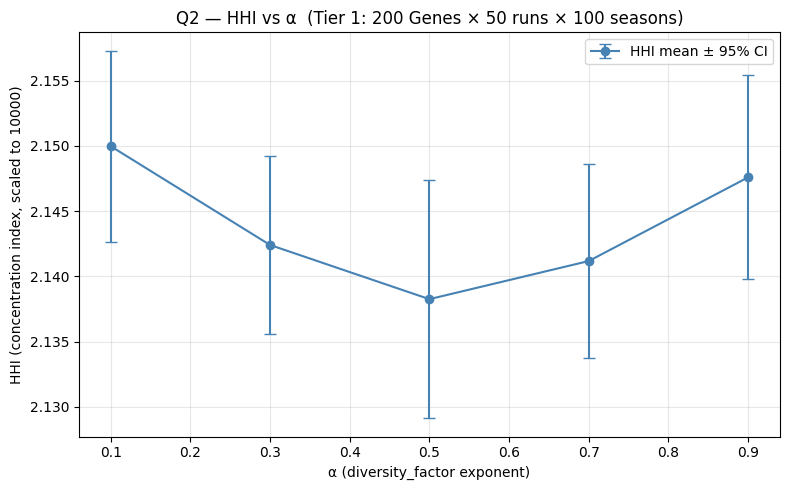

,alpha,HHI_mean,HHI_std,n,ci95
0,0.1,2.149971,0.026375,50,0.007311
1,0.3,2.142405,0.024464,50,0.006781
2,0.5,2.138255,0.032892,50,0.009117
3,0.7,2.141174,0.026705,50,0.007402
4,0.9,2.147584,0.028183,50,0.007812


In [2]:
fig, ax = plt.subplots(figsize=(8, 5))
agg = results.groupby("alpha").agg(
    HHI_mean=("HHI", "mean"),
    HHI_std=("HHI", "std"),
    n=("HHI", "count"),
).reset_index()
agg["ci95"] = 1.96 * agg["HHI_std"] / agg["n"].pow(0.5)

ax.errorbar(agg["alpha"], agg["HHI_mean"], yerr=agg["ci95"],
            fmt="o-", color="steelblue", capsize=4, label="HHI mean ± 95% CI")
ax.set_xlabel("α (diversity_factor exponent)")
ax.set_ylabel("HHI (concentration index, scaled to 10000)")
ax.set_title("Q2 — HHI vs α  (Tier 1: 200 Genes × 50 runs × 100 seasons)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(REPORT_DIR / "fig_hhi_vs_alpha.png", dpi=120)
plt.show()
agg


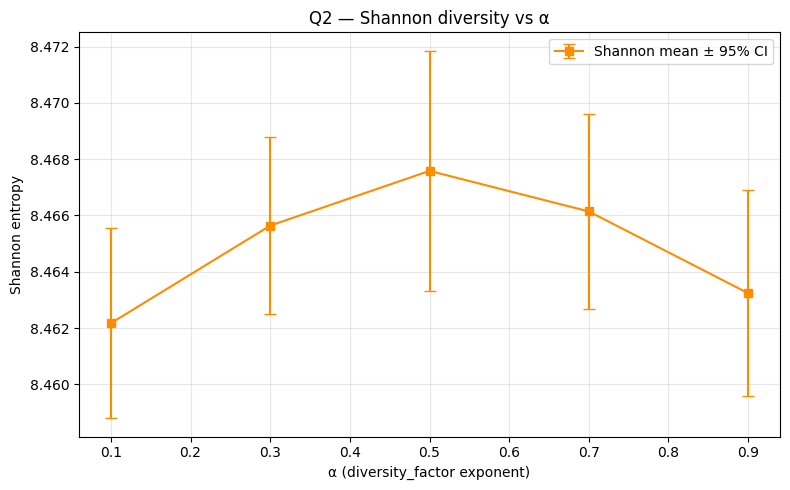

,alpha,H_mean,H_std,n,ci95
0,0.1,8.462174,0.012174,50,0.003374
1,0.3,8.465639,0.011368,50,0.003151
2,0.5,8.467583,0.015400,50,0.004269
3,0.7,8.466143,0.012492,50,0.003463
4,0.9,8.463239,0.013205,50,0.003660


In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
agg = results.groupby("alpha").agg(
    H_mean=("shannon_diversity", "mean"),
    H_std=("shannon_diversity", "std"),
    n=("shannon_diversity", "count"),
).reset_index()
agg["ci95"] = 1.96 * agg["H_std"] / agg["n"].pow(0.5)

ax.errorbar(agg["alpha"], agg["H_mean"], yerr=agg["ci95"],
            fmt="s-", color="darkorange", capsize=4,
            label="Shannon mean ± 95% CI")
ax.set_xlabel("α (diversity_factor exponent)")
ax.set_ylabel("Shannon entropy")
ax.set_title("Q2 — Shannon diversity vs α")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(REPORT_DIR / "fig_shannon_vs_alpha.png", dpi=120)
plt.show()
agg


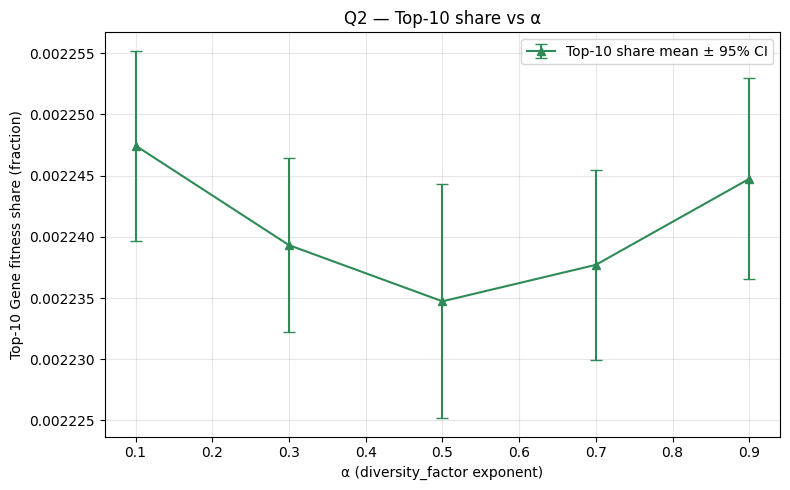

,alpha,T_mean,T_std,n,ci95
0,0.1,0.002247,0.000028,50,0.000008
1,0.3,0.002239,0.000026,50,0.000007
2,0.5,0.002235,0.000034,50,0.000010
3,0.7,0.002238,0.000028,50,0.000008
4,0.9,0.002245,0.000030,50,0.000008


In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
agg = results.groupby("alpha").agg(
    T_mean=("top10_share", "mean"),
    T_std=("top10_share", "std"),
    n=("top10_share", "count"),
).reset_index()
agg["ci95"] = 1.96 * agg["T_std"] / agg["n"].pow(0.5)

ax.errorbar(agg["alpha"], agg["T_mean"], yerr=agg["ci95"],
            fmt="^-", color="seagreen", capsize=4,
            label="Top-10 share mean ± 95% CI")
ax.set_xlabel("α (diversity_factor exponent)")
ax.set_ylabel("Top-10 Gene fitness share (fraction)")
ax.set_title("Q2 — Top-10 share vs α")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(REPORT_DIR / "fig_top10_share_vs_alpha.png", dpi=120)
plt.show()
agg


## Findings (auto-update after each sweep run)

The plots above feed directly into the report's §3 tables and §4 narrative.
Recommendation logic implemented in `reports/q2_diversity/report.md` §4.3:

1. If HHI(α=0.1) and HHI(α=0.9) **95% CI overlaps** at the chosen Tier-1 horizon,
   the spec-recommended α=0.3 vs plan-default α=0.5 is **not statistically
   distinguishable** under display-layer-only routing — log this in §6 as a
   prerequisite for the Arena-layer α experiment.
2. If they don't overlap, fit a smoothed curve and pick α at the inflection
   point as the recommended `seasons.config.diversity_factor_alpha`.

(See `reports/q2_diversity/report.md` for the written rendering.)
